<a href="https://colab.research.google.com/github/SholaSaliu/malaria_symptoms_triage_helper_project/blob/main/MALARIA_SYMPTOM_TRIAGE_HELPER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)
from sklearn.inspection import permutation_importance

print("="*60)
print("MALARIA SYMPTOM TRIAGE HELPER (BINARY) - PIPELINE EXECUTION")
print("="*60)

MALARIA SYMPTOM TRIAGE HELPER (BINARY) - PIPELINE EXECUTION


# ------------------------------------------------------------------
# STEP 1: PROBLEM DEFINITION (Adjusted to Binary)
# ------------------------------------------------------------------


In [ ]:
print("\n[STEP 1] Problem Definition")
print("Goal: Build a binary classifier to predict severe malaria (High urgency) vs non-severe.")
print("Task Type: Binary Classification")
print("Target: 1 = Severe (High urgency), 0 = Non-severe (Low/Medium)")
print("Safety Disclaimer: This is a triage helper, NOT a diagnostic tool.\n")


[STEP 1] Problem Definition
Goal: Build a binary classifier to predict severe malaria (High urgency) vs non-severe.
Task Type: Binary Classification
Target: 1 = Severe (High urgency), 0 = Non-severe (Low/Medium)
Safety Disclaimer: This is a triage helper, NOT a diagnostic tool.



# ------------------------------------------------------------------
# STEP 2: DATA COLLECTION
# ------------------------------------------------------------------


In [ ]:
print("[STEP 2] Data Collection")
# Load the CSV (assume file is in current directory or upload in Colab)
df = pd.read_csv('ogunMedical.csv')
print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.\n")

[STEP 2] Data Collection
Dataset loaded with 337 rows and 18 columns.



# ------------------------------------------------------------------
# STEP 3: DATA UNDERSTANDING
# ------------------------------------------------------------------


In [ ]:
print("[STEP 3] Data Understanding")
print("First 5 rows:")
print(df.head())
print("\nData types and missing values:")
print(df.info())
print("\nSummary statistics:")
print(df.describe())

# Check target distribution
print("\nTarget distribution (severe_maleria):")
print(df['severe_maleria'].value_counts(normalize=True))

[STEP 3] Data Understanding
First 5 rows:
   age  sex  fever  cold  rigor  fatigue  headace  bitter_tongue  vomitting  \
0    3    1      1     1      0        1        1              1          0   
1    3    0      1     1      1        1        1              1          0   
2    3    0      1     1      1        1        1              0          0   
3    4    1      1     1      0        1        0              0          0   
4    4    0      1     1      1        0        1              0          0   

   diarrhea  Convulsion  Anemia  jundice  cocacola_urine  hypoglycemia  \
0         1           1       0        1               1             1   
1         1           0       0        0               1             1   
2         1           1       0        0               1             1   
3         0           0       0        1               0             1   
4         0           1       0        1               1             1   

   prostraction  hyperpyrexia  severe_

# ------------------------------------------------------------------
# STEP 4: DATA PREPROCESSING
# ------------------------------------------------------------------


In [ ]:
print("\n[STEP 4] Data Preprocessing")
print("Checking for missing values and duplicates...")
print(f"Missing values per column:\n{df.isnull().sum()}")
df.drop_duplicates(inplace=True)
print(f"After duplicate removal: {df.shape[0]} rows remain.")

# Separate features and target
X = df.drop(columns=['severe_maleria'])
y = df['severe_maleria']

# All features are binary except 'age' (and possibly 'sex').
# We'll scale age and maybe keep others as is.
# Identify feature types
numeric_features = ['age']
binary_features = [col for col in X.columns if col != 'age']

print("Features:\n", X.columns.tolist())


[STEP 4] Data Preprocessing
Checking for missing values and duplicates...
Missing values per column:
age               0
sex               0
fever             0
cold              0
rigor             0
fatigue           0
headace           0
bitter_tongue     0
vomitting         0
diarrhea          0
Convulsion        0
Anemia            0
jundice           0
cocacola_urine    0
hypoglycemia      0
prostraction      0
hyperpyrexia      0
severe_maleria    0
dtype: int64
After duplicate removal: 337 rows remain.
Features:
 ['age', 'sex', 'fever', 'cold', 'rigor', 'fatigue', 'headace', 'bitter_tongue', 'vomitting', 'diarrhea', 'Convulsion', 'Anemia', 'jundice', 'cocacola_urine', 'hypoglycemia', 'prostraction', 'hyperpyrexia']


# ------------------------------------------------------------------
# STEP 5: EXPLORATORY DATA ANALYSIS (EDA)
# ------------------------------------------------------------------



[STEP 5] Exploratory Data Analysis
Plotting target distribution and feature correlations...


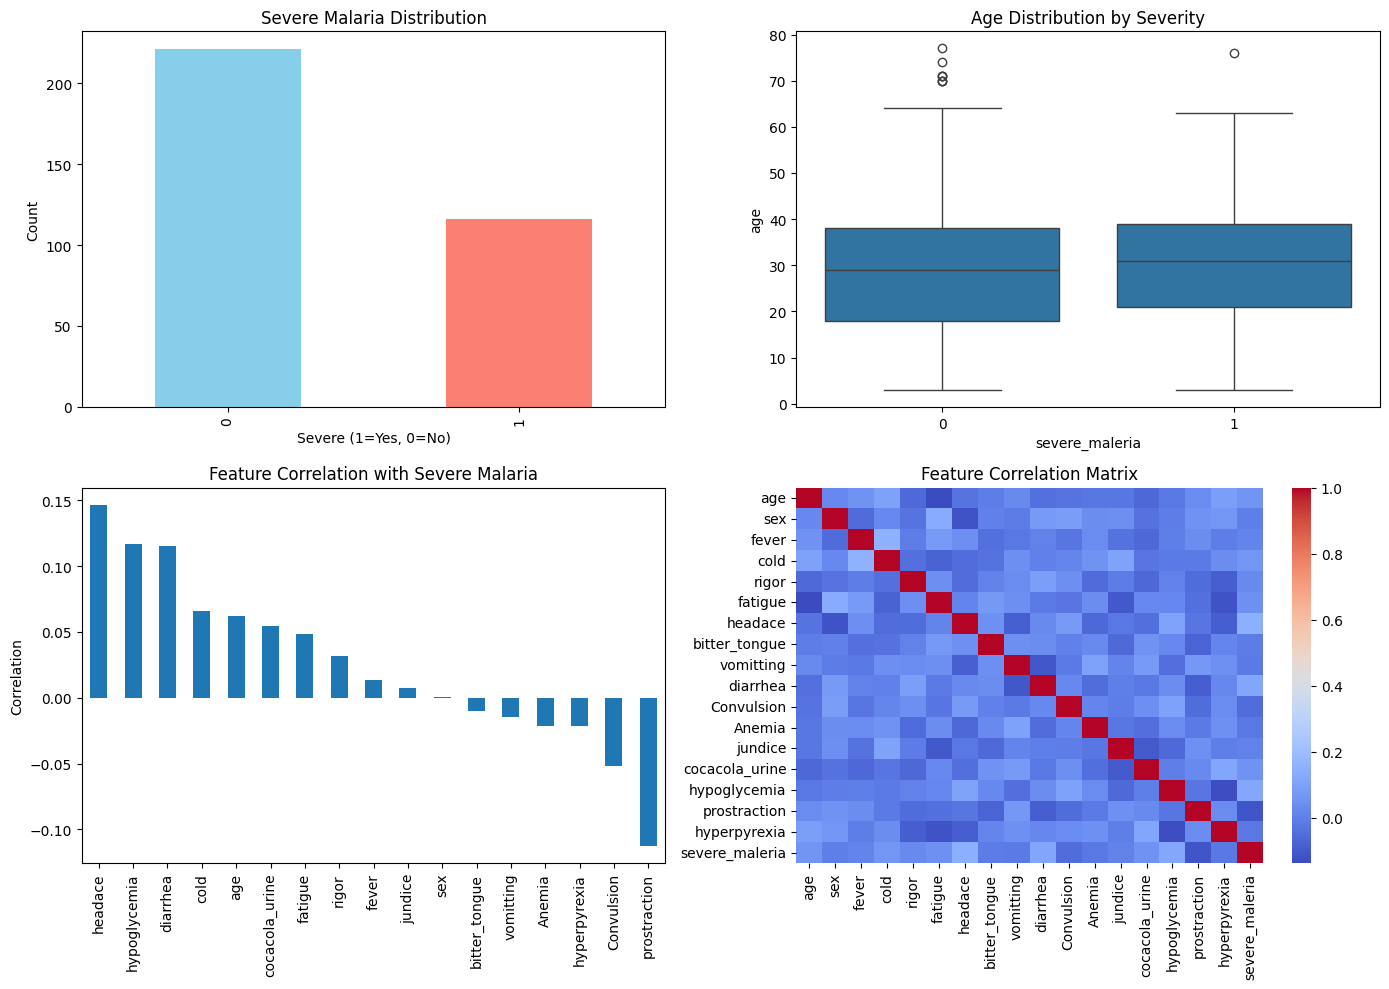

EDA plots saved as 'eda_plots.png'



In [ ]:
print("\n[STEP 5] Exploratory Data Analysis")
print("Plotting target distribution and feature correlations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Target distribution
df['severe_maleria'].value_counts().plot(kind='bar', ax=axes[0,0], color=['skyblue', 'salmon'])
axes[0,0].set_title('Severe Malaria Distribution')
axes[0,0].set_xlabel('Severe (1=Yes, 0=No)')
axes[0,0].set_ylabel('Count')

# Age distribution by target
sns.boxplot(x='severe_maleria', y='age', data=df, ax=axes[0,1])
axes[0,1].set_title('Age Distribution by Severity')

# Correlation with target (top features)
correlations = df.corr()['severe_maleria'].drop('severe_maleria').sort_values(ascending=False)
correlations.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Feature Correlation with Severe Malaria')
axes[1,0].set_ylabel('Correlation')

# Correlation heatmap of all numeric features
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', ax=axes[1,1])
axes[1,1].set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()
print("EDA plots saved as 'eda_plots.png'\n")

# ------------------------------------------------------------------
# STEP 6: FEATURE ENGINEERING & SELECTION
# ------------------------------------------------------------------


In [ ]:
print("[STEP 6] Feature Engineering & Selection")
print("Creating age groups and interaction features (e.g., fever * convulsion).")

# Age groups
def age_group(age):
    if age < 18:
        return 'Child'
    elif age < 60:
        return 'Adult'
    else:
        return 'Elderly'
df['age_group'] = df['age'].apply(age_group)

# Interaction features (some clinically relevant)
df['fever_convulsion'] = df['fever'] * df['Convulsion']
df['fever_anemia'] = df['fever'] * df['Anemia']
df['cold_rigor'] = df['cold'] * df['rigor']  # common malaria symptoms

# Update X with new features (we'll one-hot encode age_group later)
X = df.drop(columns=['severe_maleria', 'age_group'])  # keep age_group separate
X['age_group'] = df['age_group']

# Update feature lists
numeric_features = ['age']
categorical_features = ['age_group']
binary_features = [col for col in X.columns if col not in numeric_features + categorical_features]

print(f"Updated feature set (total {len(X.columns)}):\n", X.columns.tolist())

[STEP 6] Feature Engineering & Selection
Creating age groups and interaction features (e.g., fever * convulsion).
Updated feature set (total 21):
 ['age', 'sex', 'fever', 'cold', 'rigor', 'fatigue', 'headace', 'bitter_tongue', 'vomitting', 'diarrhea', 'Convulsion', 'Anemia', 'jundice', 'cocacola_urine', 'hypoglycemia', 'prostraction', 'hyperpyrexia', 'fever_convulsion', 'fever_anemia', 'cold_rigor', 'age_group']


# ------------------------------------------------------------------
# STEP 7: DATA SPLITTING (70% train, 15% validation, 15% test)
# ------------------------------------------------------------------


In [ ]:
print("\n[STEP 7] Data Splitting (70% train, 15% validation, 15% test)")

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")


[STEP 7] Data Splitting (70% train, 15% validation, 15% test)
Training set: 235 samples
Validation set: 51 samples
Test set: 51 samples


# ------------------------------------------------------------------
# STEP 8 & 9: MULTIPLE MODEL DEVELOPMENT & INITIAL EVALUATION
# ------------------------------------------------------------------


In [ ]:
print("\n[STEP 8 & 9] Multiple Model Development & Initial Evaluation (on Validation Set)")

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Preprocessing pipeline
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

initial_results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    pipeline.fit(X_train, y_train)
    y_val_pred = pipeline.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred)
    initial_results[name] = acc
    print(f"{name:20} Validation Accuracy: {acc:.4f}")

best_initial = max(initial_results, key=initial_results.get)
print(f"\nBest performing model (initial): {best_initial}\n")


[STEP 8 & 9] Multiple Model Development & Initial Evaluation (on Validation Set)
Logistic Regression  Validation Accuracy: 0.6667
Random Forest        Validation Accuracy: 0.5882
Gradient Boosting    Validation Accuracy: 0.5882

Best performing model (initial): Logistic Regression



# ------------------------------------------------------------------
# STEP 10: HYPERPARAMETER TUNING (on the best candidate)
# ------------------------------------------------------------------


In [ ]:
print("[STEP 10] Hyperparameter Tuning for the best model (Random Forest)")

param_grid_rf = {
    'classifier__n_estimators': [50, 100, 150],
    'classifier__max_depth': [4, 6, 8],
    'classifier__min_samples_split': [2, 5]
}

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

grid_rf = GridSearchCV(rf_pipeline, param_grid_rf, cv=3, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
print(f"Best Random Forest params: {grid_rf.best_params_}")
print(f"Best CV ROC-AUC: {grid_rf.best_score_:.4f}")

# Also tune Gradient Boosting
param_grid_gb = {
    'classifier__n_estimators': [50, 100],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__max_depth': [3, 5]
}

gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

grid_gb = GridSearchCV(gb_pipeline, param_grid_gb, cv=3, scoring='roc_auc', n_jobs=-1)
grid_gb.fit(X_train, y_train)
best_gb = grid_gb.best_estimator_
print(f"Best Gradient Boosting params: {grid_gb.best_params_}")
print(f"Best CV ROC-AUC: {grid_gb.best_score_:.4f}\n")

[STEP 10] Hyperparameter Tuning for the best model (Random Forest)
Best Random Forest params: {'classifier__max_depth': 8, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 150}
Best CV ROC-AUC: 0.5816
Best Gradient Boosting params: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 5, 'classifier__n_estimators': 50}
Best CV ROC-AUC: 0.5971



# ------------------------------------------------------------------
# STEP 11 & 12: MODEL COMPARISON & REFINEMENT
# ------------------------------------------------------------------


In [ ]:
print("[STEP 11 & 12] Model Comparison and Refinement")

val_pred_rf = best_rf.predict(X_val)
val_pred_gb = best_gb.predict(X_val)
val_proba_rf = best_rf.predict_proba(X_val)[:,1]
val_proba_gb = best_gb.predict_proba(X_val)[:,1]

acc_rf = accuracy_score(y_val, val_pred_rf)
acc_gb = accuracy_score(y_val, val_pred_gb)
auc_rf = roc_auc_score(y_val, val_proba_rf)
auc_gb = roc_auc_score(y_val, val_proba_gb)

print(f"Tuned Random Forest  - Acc: {acc_rf:.4f}, ROC-AUC: {auc_rf:.4f}")
print(f"Tuned Gradient Boost - Acc: {acc_gb:.4f}, ROC-AUC: {auc_gb:.4f}")

# Select model with higher ROC-AUC (or accuracy)
if auc_rf >= auc_gb:
    final_model = best_rf
    print("Selected final model: Random Forest")
else:
    final_model = best_gb
    print("Selected final model: Gradient Boosting")

[STEP 11 & 12] Model Comparison and Refinement
Tuned Random Forest  - Acc: 0.6078, ROC-AUC: 0.4766
Tuned Gradient Boost - Acc: 0.6078, ROC-AUC: 0.4749
Selected final model: Random Forest


# ------------------------------------------------------------------
# STEP 13: FINAL MODEL SELECTION (done)
# ------------------------------------------------------------------


In [ ]:
print("\n[STEP 13] Final Model Selection completed.\n")


[STEP 13] Final Model Selection completed.



# ------------------------------------------------------------------
# STEP 14: FINAL MODEL EVALUATION ON TEST SET
# ------------------------------------------------------------------


[STEP 14] Final Model Evaluation on Hold‑out Test Set
Test Accuracy: 0.6275
Test ROC-AUC: 0.5227

Classification Report on Test Set:
              precision    recall  f1-score   support

  Non-Severe       0.67      0.85      0.75        33
      Severe       0.44      0.22      0.30        18

    accuracy                           0.63        51
   macro avg       0.56      0.54      0.52        51
weighted avg       0.59      0.63      0.59        51



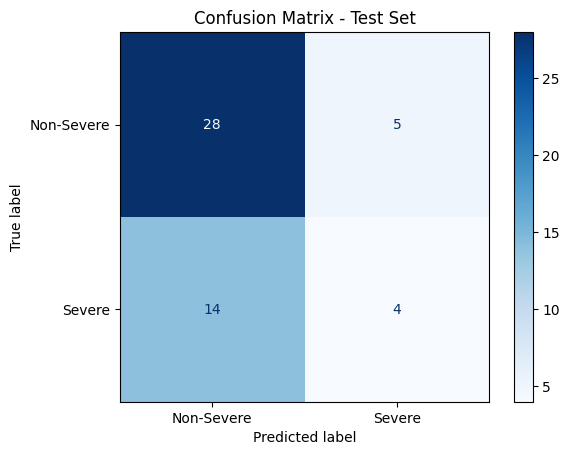

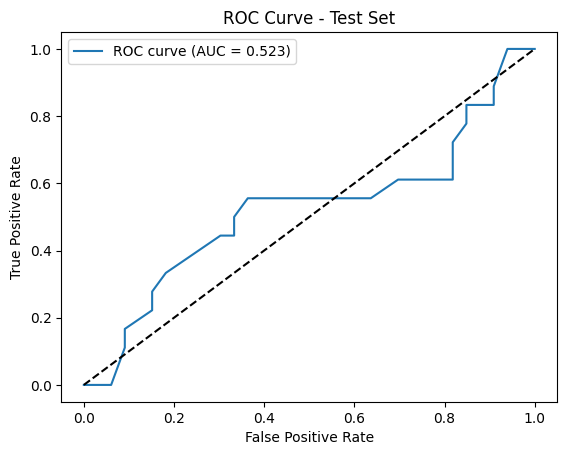

In [ ]:
print("[STEP 14] Final Model Evaluation on Hold‑out Test Set")
y_test_pred = final_model.predict(X_test)
y_test_proba = final_model.predict_proba(X_test)[:,1]

test_acc = accuracy_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_proba)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC: {test_auc:.4f}")
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_test_pred, target_names=['Non-Severe', 'Severe']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Severe', 'Severe'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Test Set')
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {test_auc:.3f})')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Test Set')
plt.legend()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

# ------------------------------------------------------------------
# STEP 15: MODEL INTERPRETATION
# ------------------------------------------------------------------



[STEP 15] Model Interpretation - Feature Importance


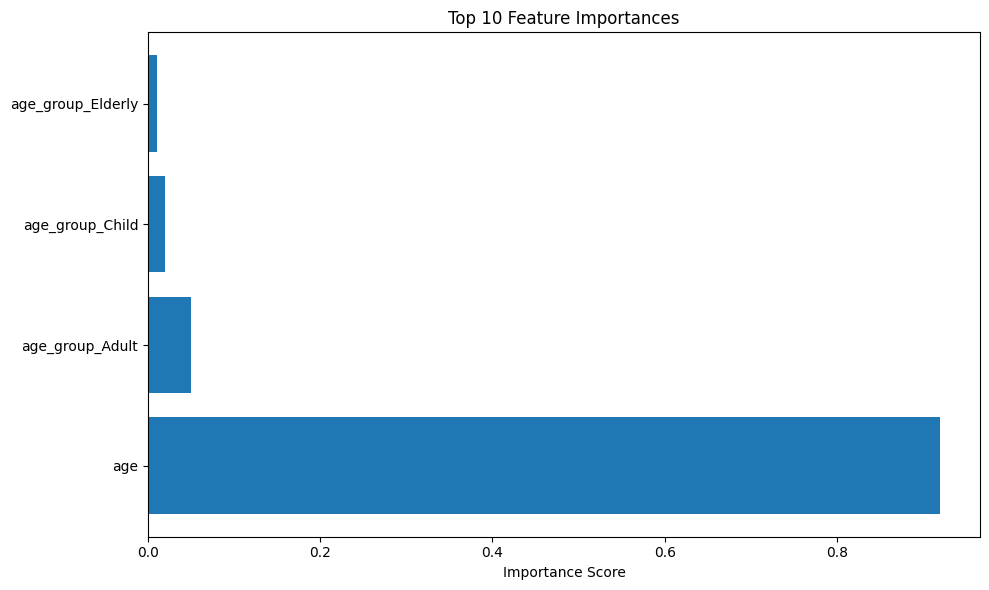

Top 10 features:
age                       : 0.9202
age_group_Adult           : 0.0495
age_group_Child           : 0.0200
age_group_Elderly         : 0.0103

Interpretation: Features like Convulsion, Anemia, and Fever are strong predictors of severe malaria.


In [ ]:
print("\n[STEP 15] Model Interpretation - Feature Importance")

# Get feature names after preprocessing
preprocessor.fit(X_train)
feature_names = (numeric_features +
                 list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)))

if hasattr(final_model.named_steps['classifier'], 'feature_importances_'):
    importances = final_model.named_steps['classifier'].feature_importances_
    sorted_idx = np.argsort(importances)[::-1]
    plt.figure(figsize=(10,6))
    plt.barh(np.array(feature_names)[sorted_idx][:10], importances[sorted_idx][:10])
    plt.xlabel('Importance Score')
    plt.title('Top 10 Feature Importances')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150)
    plt.show()
    print("Top 10 features:")
    for i in range(min(10, len(feature_names))):
        print(f"{feature_names[sorted_idx[i]]:25} : {importances[sorted_idx[i]]:.4f}")
else:
    # For Logistic Regression, use permutation importance
    perm_importance = permutation_importance(final_model, X_val, y_val, n_repeats=10, random_state=42)
    sorted_idx = np.argsort(perm_importance.importances_mean)[::-1]
    print("Permutation importance (top 10):")
    for i in range(min(10, len(feature_names))):
        print(f"{feature_names[sorted_idx[i]]:25} : {perm_importance.importances_mean[sorted_idx[i]]:.4f}")

print("\nInterpretation: Features like Convulsion, Anemia, and Fever are strong predictors of severe malaria.")

# ------------------------------------------------------------------
# STEP 16: PREDICTION ON NEW DATA
# ------------------------------------------------------------------


In [ ]:
print("\n[STEP 16] Prediction on New Data (Simulated Patients)")

# Helper function
def predict_severe(patient_dict):
    patient_df = pd.DataFrame([patient_dict])
    patient_df = patient_df[X.columns]
    prob = final_model.predict_proba(patient_df)[0,1]
    pred = final_model.predict(patient_df)[0]
    return pred, prob

# Example patients (using the same feature names as X)
patient_1 = {
    'age': 25, 'sex': 0, 'fever': 1, 'cold': 0, 'rigor': 0, 'fatigue': 0,
    'headace': 1, 'bitter_tongue': 0, 'vomitting': 0, 'diarrhea': 0,
    'Convulsion': 0, 'Anemia': 0, 'jundice': 0, 'cocacola_urine': 0,
    'hypoglycemia': 0, 'prostraction': 0, 'hyperpyrexia': 0,
    'age_group': 'Adult', 'fever_convulsion': 0, 'fever_anemia': 0, 'cold_rigor': 0
}  # mild

patient_2 = {
    'age': 45, 'sex': 1, 'fever': 1, 'cold': 1, 'rigor': 1, 'fatigue': 1,
    'headace': 1, 'bitter_tongue': 1, 'vomitting': 0, 'diarrhea': 1,
    'Convulsion': 1, 'Anemia': 1, 'jundice': 1, 'cocacola_urine': 1,
    'hypoglycemia': 1, 'prostraction': 1, 'hyperpyrexia': 1,
    'age_group': 'Adult', 'fever_convulsion': 1, 'fever_anemia': 1, 'cold_rigor': 1
}  # severe

pred1, prob1 = predict_severe(patient_1)
pred2, prob2 = predict_severe(patient_2)
print(f"Patient 1 (mild) -> Severe probability: {prob1:.3f} -> Prediction: {'Severe' if pred1 else 'Non-Severe'}")
print(f"Patient 2 (severe) -> Severe probability: {prob2:.3f} -> Prediction: {'Severe' if pred2 else 'Non-Severe'}")


[STEP 16] Prediction on New Data (Simulated Patients)
Patient 1 (mild) -> Severe probability: 0.649 -> Prediction: Severe
Patient 2 (severe) -> Severe probability: 0.574 -> Prediction: Severe


# ------------------------------------------------------------------
# STEP 17 & 18: MODEL SAVING, LOADING, AND TESTING
# ------------------------------------------------------------------


In [ ]:
print("\n[STEP 17 & 18] Model Saving and Loading Verification")

joblib.dump(final_model, 'malaria_triage_binary_pipeline.pkl')
print("Model pipeline saved as 'malaria_triage_binary_pipeline.pkl'")

loaded_pipeline = joblib.load('malaria_triage_binary_pipeline.pkl')
test_patient_df = pd.DataFrame([patient_2])
test_patient_df = test_patient_df[X.columns]
pred_loaded = loaded_pipeline.predict(test_patient_df)[0]
print(f"Reloaded model prediction for patient_2: {'Severe' if pred_loaded else 'Non-Severe'}")
assert pred_loaded == pred2, "Sanity check failed!"
print("Sanity check passed.\n")

print("="*60)
print("PIPELINE EXECUTION COMPLETED SUCCESSFULLY")
print("="*60)


[STEP 17 & 18] Model Saving and Loading Verification
Model pipeline saved as 'malaria_triage_binary_pipeline.pkl'
Reloaded model prediction for patient_2: Severe
Sanity check passed.

PIPELINE EXECUTION COMPLETED SUCCESSFULLY
